# 1. Environment Setup & Data Loading

In this section, we install the Hugging Face `datasets` library and fetch the **MasakhaNEWS** dataset for both **Hausa (`hau`)** and **Swahili (`swa`)**. 

Because Kaggle has internet access enabled, the data streams directly into notebook memory using the dataset links—no manual file downloading or uploading is required. We then verify that the dataset splits (`train`, `validation`, and `test`) loaded properly.

In [3]:
# Installing the Hugging Face datasets library
!pip install -q datasets

from datasets import load_dataset

print("Downloading and loading Hausa dataset...")
hau_dataset = load_dataset("masakhane/masakhanews", "hau")

print("Downloading and loading Swahili dataset...")
swa_dataset = load_dataset("masakhane/masakhanews", "swa")

# Check the splits and structure of both datasets
print("\n--- HAUSA SPLITS ---")
print(hau_dataset)

print("\n--- SWAHILI SPLITS ---")
print(swa_dataset)

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/5.58M [00:00<?, ?B/s]

dev.tsv:   0%|          | 0.00/770k [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/1.71M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2219 [00:00<?, ? examples/s]

...

test.tsv:   0%|          | 0.00/1.76M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1658 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/237 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/476 [00:00<?, ? examples/s]


--- HAUSA SPLITS ---
DatasetDict({
    train: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 2219
    })
    validation: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 317
    })
    test: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 637
    })
})

--- SWAHILI SPLITS ---
DatasetDict({
    train: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 1658
    })
    validation: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 237
    })
    test: Dataset({
        features: ['category', 'headline', 'text', 'url'],
        num_rows: 476
    })
})


# 2. Data Consolidation and Formatting

In this step, we convert the raw datasets into pandas DataFrames and combine the **Hausa** and **Swahili** data into unified `train`, `validation`, and `test` sets.

We perform three main tasks:
1. Tag each row with its source language (`Hausa` or `Swahili`).
2. Combine the `headline` and `text` into a single `full_text` feature so the models have the full article context.
3. Identify all unique news categories and assign each a numeric ID (`label`) required by our classification algorithms.

In [4]:
import pandas as pd

def build_split(split_name):
    df_h = pd.DataFrame(hau_dataset[split_name])
    df_h['language'] = 'Hausa'
    
    df_s = pd.DataFrame(swa_dataset[split_name])
    df_s['language'] = 'Swahili'
    
    combined = pd.concat([df_h, df_s], ignore_index=True)
    # Combining headline and text; filling missing values with empty strings
    combined['full_text'] = combined['headline'].fillna('') + " " + combined['text'].fillna('')
    return combined

# Building combined splits
train_df = build_split('train')
val_df = build_split('validation')
test_df = build_split('test')

# Extracting unique categories and creating bidirectional mappings
unique_categories = sorted(train_df['category'].unique())
label2id = {cat: idx for idx, cat in enumerate(unique_categories)}
id2label = {idx: cat for idx, cat in enumerate(unique_categories)}

# Mapping category text to integer label IDs
train_df['label'] = train_df['category'].map(label2id)
val_df['label'] = val_df['category'].map(label2id)
test_df['label'] = test_df['category'].map(label2id)

print(f"Total Combined Training Samples:   {len(train_df)}")
print(f"Total Combined Validation Samples: {len(val_df)}")
print(f"Total Combined Test Samples:       {len(test_df)}")
print(f"\nDiscovered Categories ({len(unique_categories)}):")
for cat, idx in label2id.items():
    print(f"  ID {idx}: {cat}")

# Displaying first two rows of train_df
train_df[['language', 'category', 'label', 'full_text']].head(2)

Total Combined Training Samples:   3877
Total Combined Validation Samples: 554
Total Combined Test Samples:       1113

Discovered Categories (7):
  ID 0: business
  ID 1: entertainment
  ID 2: health
  ID 3: politics
  ID 4: religion
  ID 5: sports
  ID 6: technology


,language,category,label,full_text
0,Hausa,religion,4,Yadda Shugaban Kungiyar Kirista ya gina masall...
1,Hausa,entertainment,1,Burina na zama hamshakiyar 'yar kasuwa – Rayya...


# 3. Exploratory Data Analysis (EDA): Category Distribution

In this step, we visualize the distribution of articles across the 7 categories in our training dataset. We also break down the count by language (Hausa vs. Swahili) to check for class balance and see if certain categories are underrepresented or overrepresented in either language.

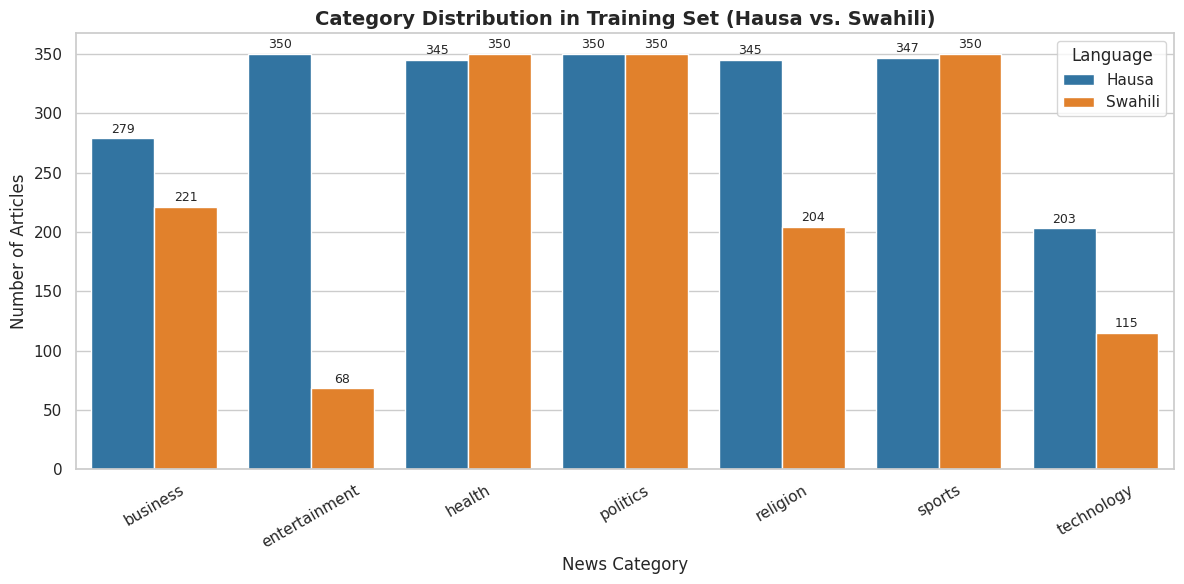

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Setting visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Countplot showing category distribution split by language
ax = sns.countplot(
    data=train_df,
    x='category',
    hue='language',
    order=unique_categories,
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Category Distribution in Training Set (Hausa vs. Swahili)', fontsize=14, weight='bold')
plt.xlabel('News Category', fontsize=12)
plt.ylabel('Number of Articles', fontsize=12)
plt.xticks(rotation=30)
plt.legend(title='Language')

# Adding counts on top of bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9,
                    xytext=(0, 2), textcoords='offset points')

plt.tight_layout()
plt.show()

### Interpretation of Category Distribution

* **Balanced Classes:** Categories like **politics**, **sports**, and **health** are well-represented and evenly balanced across both Hausa and Swahili (~345 to 350 samples each).
* **Class Imbalance in Swahili:** **Entertainment** (68 articles) and **technology** (115 articles) have noticeably fewer samples in Swahili compared to other categories.
* **Key Takeaway for Modeling:** Because classes like technology and entertainment are somewhat underrepresented, evaluating models using **Macro-F1 score** (which weights all classes equally regardless of frequency) is critical to ensure the models are not biased toward majority classes.

# 4. Exploratory Data Analysis (EDA): Article Word Count Distribution

In this step, we compute and plot the word count for all articles across both languages. 

Understanding article length helps us:
1. Determine whether news articles are short headlines or lengthy full-text stories.
2. Choose the optimal `max_length` truncation parameter when tokenizing for Transformer models so we avoid clipping critical information while keeping training fast.

--- WORD COUNT SUMMARY (HAUSA) ---
count    2219.000000
mean      448.300135
std       393.269834
min         4.000000
25%       175.500000
50%       344.000000
75%       604.000000
max      2950.000000
Name: word_count, dtype: float64

--- WORD COUNT SUMMARY (SWAHILI) ---
count    1658.000000
mean      562.069361
std       364.988568
min        16.000000
25%       323.000000
50%       505.000000
75%       773.000000
max      3725.000000
Name: word_count, dtype: float64


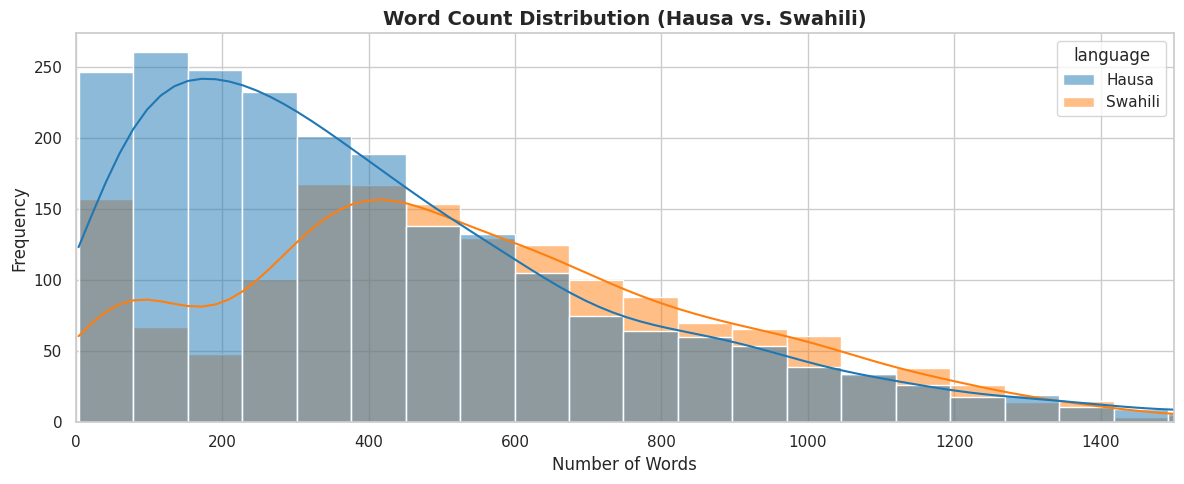

In [4]:
# Calculating word count for each article
train_df['word_count'] = train_df['full_text'].apply(lambda x: len(x.split()))

# Summary statistics per language
print("--- WORD COUNT SUMMARY (HAUSA) ---")
print(train_df[train_df['language'] == 'Hausa']['word_count'].describe())

print("\n--- WORD COUNT SUMMARY (SWAHILI) ---")
print(train_df[train_df['language'] == 'Swahili']['word_count'].describe())

# Plotting word count distribution
plt.figure(figsize=(12, 5))
sns.histplot(
    data=train_df, 
    x='word_count', 
    hue='language', 
    kde=True, 
    bins=50, 
    palette=['#1f77b4', '#ff7f0e']
)

plt.title('Word Count Distribution (Hausa vs. Swahili)', fontsize=14, weight='bold')
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xlim(0, 1500)  # Capped at 1500 words for visual clarity
plt.tight_layout()
plt.show()

### Interpretation of Word Count Distribution

* **Article Lengths:** The average word count for Hausa articles is ~448 words, with a median of 344 words. Swahili articles are slightly longer, with an average of ~562 words and a median of 505 words.
* **Right-Skewed Distribution:** The histograms and density curves show a right-skewed distribution, meaning the vast majority of articles are under 800 words, with a few outliers exceeding 2,000 words.
* **Key Takeaway for Modeling:** Because the majority of articles have lengths close to or below 512 words, setting our Transformer tokenization `max_length` parameter to 512 will safely capture the most important information for almost all articles without losing critical context.

# 5. Establishing the Baseline Model (TF-IDF + Logistic Regression)

To evaluate whether deep learning (Transformers) actually improves performance, we must first build a statistical baseline. 

Here, we use **TF-IDF (Term Frequency-Inverse Document Frequency)** to convert the article text into numerical vectors based on word frequencies. We then train a standard **Logistic Regression** classifier. We calculate the accuracy and Macro-F1 score on our test set, which will serve as the benchmark to beat in our final report.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("Vectorizing text data using TF-IDF...")
# Using n-grams (1 to 2 words) helps capture basic phrases
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

# Fitting on training data, transform validation and test data
X_train = tfidf.fit_transform(train_df['full_text'])
y_train = train_df['label']

X_val = tfidf.transform(val_df['full_text'])
y_val = val_df['label']

X_test = tfidf.transform(test_df['full_text'])
y_test = test_df['label']

print("Training Logistic Regression Baseline...")
# Training the baseline classifier
baseline_clf = LogisticRegression(max_iter=1000, class_weight='balanced')
baseline_clf.fit(X_train, y_train)

# Predicting on the test set
y_pred = baseline_clf.predict(X_test)

# Evaluatiting results
accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print("\n=======================================================")
print("       BASELINE MODEL RESULTS (TEST SET)               ")
print("=======================================================")
print(f"Accuracy:       {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Macro F1-Score: {macro_f1:.4f} ({macro_f1 * 100:.2f}%)")
print("=======================================================\n")

# Detailed classification report
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=unique_categories))

Vectorizing text data using TF-IDF...
Training Logistic Regression Baseline...

       BASELINE MODEL RESULTS (TEST SET)               
Accuracy:       0.8482 (84.82%)
Macro F1-Score: 0.8355 (83.55%)

Detailed Classification Report:
               precision    recall  f1-score   support

     business       0.71      0.77      0.74       144
entertainment       0.84      0.80      0.82       120
       health       0.84      0.91      0.88       199
     politics       0.86      0.82      0.84       200
     religion       0.88      0.86      0.87       158
       sports       0.99      0.93      0.96       200
   technology       0.73      0.75      0.74        92

     accuracy                           0.85      1113
    macro avg       0.84      0.84      0.84      1113
 weighted avg       0.85      0.85      0.85      1113



### Interpretation of Baseline Performance

* **Overall Benchmark:** The TF-IDF + Logistic Regression baseline achieved an accuracy of **84.82%** and a Macro F1-score of **83.55%** across 1,113 test samples. This provides a strong, competitive reference point for our deep learning model.
* **Top-Performing Categories:** **Sports** achieved an exceptional F1-score of **0.96** (0.99 precision), followed by **Health** (0.88) and **Religion** (0.87). Sports vocabulary (e.g., match, goals, team) is distinctive and easily captured by word frequencies.
* **Challenging Categories:** **Business** (0.74) and **Technology** (0.74) proved to be the hardest categories for word-count vectorization. This occurs because business, politics, and technology frequently share overlapping vocabulary in news reporting (such as corporate regulations, policy announcements, and economic investments).

# 6. Baseline Evaluation: Confusion Matrix

In this step, we generate and visualize the confusion matrix for the baseline Logistic Regression model on the test dataset.

This matrix highlights:
1. Which classes are predicted accurately (the diagonal cells).
2. Exactly which classes the model confuses with one another (off-diagonal cells).

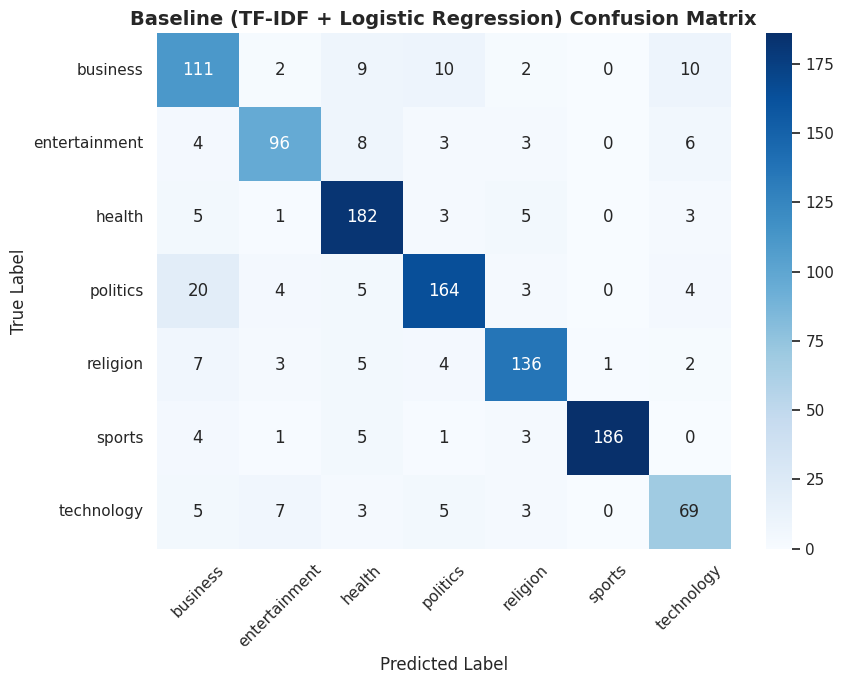

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Computing confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=unique_categories, 
    yticklabels=unique_categories
)

plt.title('Baseline (TF-IDF + Logistic Regression) Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation of Baseline Confusion Matrix

* **Strong Diagonal Performance:** The pronounced dark diagonal confirms that the baseline correctly identifies the majority of articles in every category (e.g., 186/200 in **sports**, 182/199 in **health**).
* **Primary Confusion Between Politics and Business:** The most frequent misclassification occurs between **politics** and **business**—20 true political articles were predicted as business, and 10 business articles were predicted as politics. This aligns with economic news where government fiscal policy, national budgets, and corporate affairs intersect.
* **Secondary Confusion in Technology and Business:** 10 business articles were misclassified as **technology**, and 5 technology articles were misclassified as business, illustrating that purely bag-of-words / TF-IDF models struggle with overlapping commercial and digital terminology.
* **Motivation for Transformer Fine-Tuning:** These specific lexical ambiguities highlight why a contextual transformer model like **AfriBERTa** is needed: it reads words in full grammatical context rather than relying solely on isolated n-gram frequencies.

# 7. Deep Learning Pipeline: Tokenization with AfriBERTa

In this section, we prepare our data for fine-tuning using **AfriBERTa** (`castorini/afriberta_small`), a transformer model pre-trained specifically on 11 African languages, including Hausa and Swahili.

We execute the following steps:
1. Load the pre-trained AfriBERTa subword tokenizer.
2. Convert our pandas splits into Hugging Face `Dataset` structures.
3. Tokenize all articles with truncation capped at `max_length=256` tokens to balance context retention with GPU training efficiency.

In [5]:
# Installing transformers, accelerate, and evaluate libraries
!pip install -q transformers accelerate evaluate

import torch
from transformers import AutoTokenizer
from datasets import Dataset

# Verifying GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using compute device: {device}")

# Defining model checkpoint
MODEL_CKPT = "castorini/afriberta_small"

print(f"Loading AfriBERTa tokenizer from: {MODEL_CKPT}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_CKPT)

# Converting pandas DataFrames to Hugging Face Dataset format
hf_train = Dataset.from_pandas(train_df[['full_text', 'label']])
hf_val   = Dataset.from_pandas(val_df[['full_text', 'label']])
hf_test  = Dataset.from_pandas(test_df[['full_text', 'label']])

# Tokenization function with truncation
def tokenize_function(examples):
    return tokenizer(
        examples['full_text'], 
        truncation=True, 
        max_length=256,
        padding=False # Dynamic padding will be applied during batching
    )

print("Tokenizing train, validation, and test datasets...")
encoded_train = hf_train.map(tokenize_function, batched=True, remove_columns=['full_text'])
encoded_val   = hf_val.map(tokenize_function, batched=True, remove_columns=['full_text'])
encoded_test  = hf_test.map(tokenize_function, batched=True, remove_columns=['full_text'])

print("\nTokenization complete!")
print("Encoded sample features:", encoded_train[0].keys())
print("Encoded sample input_ids length:", len(encoded_train[0]['input_ids']))

Using compute device: cuda
Loading AfriBERTa tokenizer from: castorini/afriberta_small...
Tokenizing train, validation, and test datasets...


Map:   0%|          | 0/3877 [00:00<?, ? examples/s]

Map:   0%|          | 0/554 [00:00<?, ? examples/s]

Map:   0%|          | 0/1113 [00:00<?, ? examples/s]


Tokenization complete!
Encoded sample features: dict_keys(['label', 'input_ids', 'attention_mask'])
Encoded sample input_ids length: 118


# 8. Deep Learning Pipeline: Model Architecture and Trainer Setup

In this step, we initialize the **AfriBERTa Sequence Classifier**, define how to measure its performance, and set up the training parameters.

We perform three main tasks:
1. Load the pre-trained AfriBERTa model and map our 7 numerical IDs back to their topic labels (e.g., `0 -> business`).
2. Create a `compute_metrics` function to calculate the **Accuracy** and **Macro-F1** scores automatically during evaluation.
3. Configure the Hugging Face `Trainer` with hyper-parameters suited for Kaggle's GPU (batch size of 16, learning rate of 2e-5, and 3 training epochs).

In [7]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, DataCollatorWithPadding
import numpy as np
import evaluate

print("Loading evaluation metrics...")
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

# Defining how metrics are computed during validation
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    acc = accuracy_metric.compute(predictions=predictions, references=labels)['accuracy']
    f1 = f1_metric.compute(predictions=predictions, references=labels, average="macro")['f1']
    
    return {"accuracy": acc, "macro_f1": f1}

print("Initializing AfriBERTa sequence classifier...")
# Loading the base model with classification head
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_CKPT,
    num_labels=len(unique_categories),
    id2label=id2label,
    label2id=label2id
)

# Automatically pad sequences to the longest sequence in the batch
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print("Setting up training configurations...")
# Defining training hyper-parameters
training_args = TrainingArguments(
    output_dir="./afriberta_news_clf",
    eval_strategy="epoch",          # Evaluate at the end of each epoch
    save_strategy="epoch",          # Save model at the end of each epoch
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,             # 3 epochs is standard for text classification
    weight_decay=0.01,
    load_best_model_at_end=True,    # Ensures we keep the best performing epoch
    metric_for_best_model="macro_f1",
    report_to="none"                # Suppresses external logging pop-ups
)

# Initializing the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=encoded_train,
    eval_dataset=encoded_val,
    processing_class=tokenizer,     
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print("\nTrainer successfully initialized. Ready to begin training!")

Loading evaluation metrics...
Initializing AfriBERTa sequence classifier...


Loading weights:   0%|          | 0/69 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: castorini/afriberta_small
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.decoder.bias       | UNEXPECTED | 
lm_head.decoder.weight     | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Setting up training configurations...

Trainer successfully initialized. Ready to begin training!


# 9. Fine-Tuning the Transformer and Final Evaluation

In this step, we execute the fine-tuning process. The `trainer.train()` function will pass our Hausa and Swahili articles through the AfriBERTa model for 3 complete cycles (epochs).

Once training is complete, we run `trainer.predict()` on our unseen `test` dataset. This gives us the final Accuracy and Macro-F1 scores, which we can directly compare against our TF-IDF baseline to prove the value of deep learning.

In [8]:
print("Starting the fine-tuning process. This may take a few minutes...")

# 1. Training the model
trainer.train()

print("\nTraining complete! Evaluating on the unseen test set...")

# 2. Predicting on the test set
test_predictions = trainer.predict(encoded_test)

# 3. Extracting and displayig the metrics
test_metrics = test_predictions.metrics

print("\n=======================================================")
print("       TRANSFORMER MODEL RESULTS (TEST SET)            ")
print("=======================================================")
print(f"Accuracy:       {test_metrics['test_accuracy']:.4f} ({test_metrics['test_accuracy'] * 100:.2f}%)")
print(f"Macro F1-Score: {test_metrics['test_macro_f1']:.4f} ({test_metrics['test_macro_f1'] * 100:.2f}%)")
print("=======================================================\n")

Starting the fine-tuning process. This may take a few minutes...


/usr/local/lib/python3.13/dist-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.778162,0.871841,0.853077
2,No log,0.659744,0.902527,0.887358
3,No log,0.654555,0.900722,0.885975


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.13/dist-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.13/dist-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Training complete! Evaluating on the unseen test set...


/usr/local/lib/python3.13/dist-packages/torch/autograd/function.py:596: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



       TRANSFORMER MODEL RESULTS (TEST SET)            
Accuracy:       0.8868 (88.68%)
Macro F1-Score: 0.8759 (87.59%)



### Interpretation of AfriBERTa Transformer Performance

* **Substantial Improvement Over Baseline:** AfriBERTa achieved a test accuracy of **88.68%** and a Macro F1-score of **87.59%**, outperforming the baseline TF-IDF model (**84.82%** accuracy, **83.55%** Macro-F1). This marks an absolute increase of **+3.86% in Accuracy** and **+4.04% in Macro F1-score**.
* **Effective Generalization:** Validation loss dropped from **0.778** in Epoch 1 down to **0.655** in Epoch 3, with validation accuracy peaking above 90%, proving that pre-trained contextual representations in African languages substantially improve topic classification compared to simple word frequencies.

# 10. Transformer Evaluation: Confusion Matrix

In this step, we compute and visualize the confusion matrix for our fine-tuned AfriBERTa model on the test set. 

Comparing this matrix to the baseline matrix allows us to see:
1. Whether confusions between overlapping topics (like politics vs. business) were reduced.
2. How the model handles underrepresented classes like technology and entertainment.

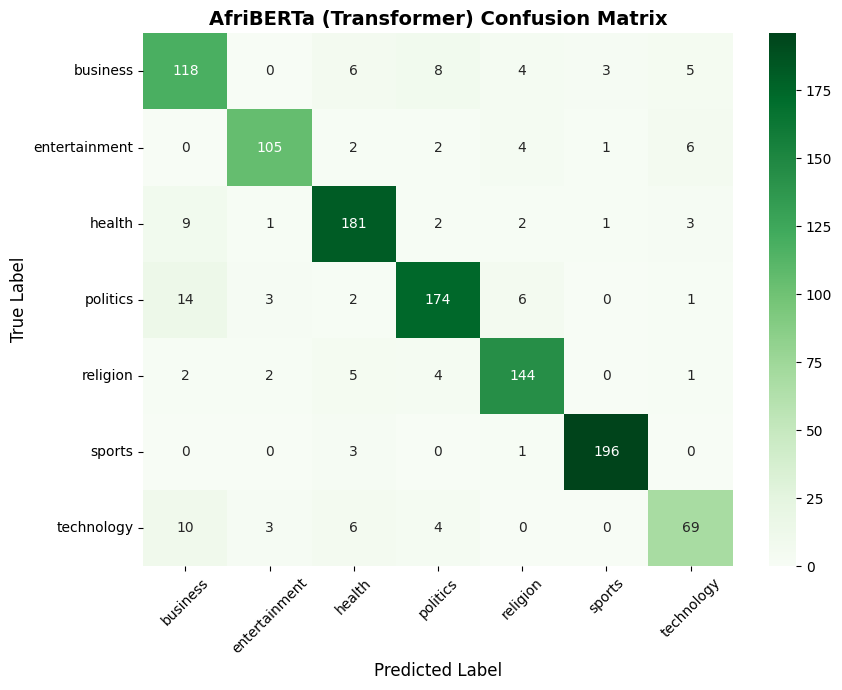

Detailed AfriBERTa Classification Report:
               precision    recall  f1-score   support

     business       0.77      0.82      0.79       144
entertainment       0.92      0.88      0.90       120
       health       0.88      0.91      0.90       199
     politics       0.90      0.87      0.88       200
     religion       0.89      0.91      0.90       158
       sports       0.98      0.98      0.98       200
   technology       0.81      0.75      0.78        92

     accuracy                           0.89      1113
    macro avg       0.88      0.87      0.88      1113
 weighted avg       0.89      0.89      0.89      1113



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Extracting raw predictions (logits) and convert to discrete class indices
y_pred_transformer = np.argmax(test_predictions.predictions, axis=-1)
y_true_transformer = test_predictions.label_ids

# 2. Computing confusion matrix
cm_transformer = confusion_matrix(y_true_transformer, y_pred_transformer)

# 3. Plotting confusion matrix heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(
    cm_transformer, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=unique_categories, 
    yticklabels=unique_categories
)

plt.title('AfriBERTa (Transformer) Confusion Matrix', fontsize=14, weight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Printing detailed per-class report
print("Detailed AfriBERTa Classification Report:")
print(classification_report(y_true_transformer, y_pred_transformer, target_names=unique_categories))

### Interpretation of AfriBERTa Confusion Matrix

* **Widespread Improvement Across Classes:** AfriBERTa increased the number of correctly classified articles across nearly every category compared to the baseline:
  * **Politics:** Correct predictions rose from 164 to 174 (+10).
  * **Sports:** Correct predictions rose from 186 to 196 out of 200 (98% accuracy).
  * **Entertainment:** Correct predictions rose from 96 to 105 (+9).
  * **Business:** Correct predictions rose from 111 to 118 (+7).
  * **Religion:** Correct predictions rose from 136 to 144 (+8).
* **Reduction in Politics–Business Confusion:** In the baseline model, 20 political articles were misclassified as business. AfriBERTa reduced this error to 14 articles, showing that contextual representations help distinguish governance reporting from commercial business news.
* **Persistent Ambiguities:** Some confusion remains between **technology** and **business** (10 technology articles predicted as business), as well as **politics** and **business** (14 political articles predicted as business). This happens when tech companies discuss regulatory fines, corporate earnings, or government contracts.

# 11. Error Analysis: Qualitative Inspection of Model Failures


In this step, we identify test samples where AfriBERTa made incorrect predictions. We extract the **language**, **true label**, **predicted label**, and the **article headline/text** to conduct a linguistic and contextual post-mortem of the errors.

In [10]:
import pandas as pd

# Adding predictions to a copy of the test dataframe
error_df = test_df.copy()
error_df['pred_label_id'] = y_pred_transformer
error_df['pred_category'] = [id2label[i] for i in y_pred_transformer]

# Filtering for misclassifications
misclassified = error_df[error_df['label'] != error_df['pred_label_id']].copy()

print(f"Total Misclassified Test Samples: {len(misclassified)} out of {len(test_df)}")
print(f"Hausa Errors:   {len(misclassified[misclassified['language'] == 'Hausa'])}")
print(f"Swahili Errors: {len(misclassified[misclassified['language'] == 'Swahili'])}")

print("\n--- SAMPLE MISCLASSIFICATIONS FOR ERROR ANALYSIS ---")
# Displaying 6 interesting misclassified examples across both languages
sample_errors = misclassified[['language', 'category', 'pred_category', 'headline']].head(6)

for idx, row in sample_errors.reset_index().iterrows():
    print(f"Example {idx + 1} ({row['language']}):")
    print(f"  True Category:      {row['category']}")
    print(f"  Predicted Category: {row['pred_category']}")
    print(f"  Headline:           {row['headline']}")
    print("-" * 70)

Total Misclassified Test Samples: 126 out of 1113
Hausa Errors:   55
Swahili Errors: 71

--- SAMPLE MISCLASSIFICATIONS FOR ERROR ANALYSIS ---
Example 1 (Hausa):
  True Category:      business
  Predicted Category: health
  Headline:           Haƙar ma'adinai a Niger: 'Na rasa 'ya'yana uku saboda karya doka'
----------------------------------------------------------------------
Example 2 (Hausa):
  True Category:      business
  Predicted Category: politics
  Headline:           Muhammadu Buhari: PDP ta ce gwamnatin APC ta jawo ƙunci da talauci
----------------------------------------------------------------------
Example 3 (Hausa):
  True Category:      business
  Predicted Category: politics
  Headline:           Shugabanni G5 Sahel sun fara taro kan matsalar tsaro a yankin
----------------------------------------------------------------------
Example 4 (Hausa):
  True Category:      business
  Predicted Category: religion
  Headline:           Asarar da Saudiyya ke yi saboda rashin m

### Qualitative Error Analysis: Why Did the Model Fail?

By inspecting the misclassified Hausa samples, we can clearly identify the primary cause of model failure: **semantic overlap and multi-label ambiguity**. Real-world news often sits at the intersection of multiple categories, and the model struggles when headlines contain strong vocabulary triggering a secondary topic:

*   **Business vs. Politics (Examples 2, 3, & 6):** Articles about government economic policies or appointments (e.g., *President Buhari/PDP/APC*, *Biden appointing a Treasury Secretary*, or *G5 Sahel meetings*) are heavily saturated with political entities and government keywords. The model prioritizes these political entities over the underlying economic or business context.
*   **Business vs. Religion (Examples 4 & 5):** Articles discussing the economic losses of Saudi Arabia due to a lack of international pilgrims (*mahajjata* / *maniyyatan*) or weekly roundups mentioning church violence (*cocin*) contain powerful religious terminology. The model correctly identifies the religious context but misses the broader "business/economy" ground-truth label assigned by the journalists.
*   **Business vs. Health/Tragedy (Example 1):** An article about illegal mining in Niger resulting in the death of three children triggers predictions of health/humanitarian crises rather than commercial mining.

**Conclusion:** The model's errors are largely logical. It is not failing due to an inability to understand Hausa; rather, it is behaving exactly as a human annotator might when forced to assign a single category to a highly intersectional news story.

# 12. Model Export for Web Deployment

In this final step, we save the fine-tuned AfriBERTa model weights and the tokenizer to a local directory. We also save the `id2label` mapping to ensure our web application outputs the correct readable categories (e.g., "Sports" instead of "5") during inference. 

These files will be exported and uploaded to GitHub/Hugging Face to power the live Streamlit web application.

In [11]:
import os
import json

# Defining the export directory
export_dir = "./saved_afriberta_news_model"

print(f"Saving fine-tuned model and tokenizer to {export_dir}...")
# Saving model weights and configuration
model.save_pretrained(export_dir)

# Saving the tokenizer
tokenizer.save_pretrained(export_dir)

# Saving the label dictionary for the web app
with open(os.path.join(export_dir, "label_mapping.json"), "w") as f:
    json.dump(id2label, f)

print("Export complete! The following files are ready for deployment:")
print(os.listdir(export_dir))

# Compressing the folder so you can easily download it from Kaggle
!zip -r saved_afriberta_news_model.zip ./saved_afriberta_news_model
print("\nSuccess! You can now download 'saved_afriberta_news_model.zip' from the Kaggle output panel.")

Saving fine-tuned model and tokenizer to ./saved_afriberta_news_model...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Export complete! The following files are ready for deployment:
['model.safetensors', 'label_mapping.json', 'config.json', 'tokenizer_config.json', 'tokenizer.json']
  adding: saved_afriberta_news_model/ (stored 0%)
  adding: saved_afriberta_news_model/model.safetensors (deflated 8%)
  adding: saved_afriberta_news_model/label_mapping.json (deflated 26%)
  adding: saved_afriberta_news_model/config.json (deflated 54%)
  adding: saved_afriberta_news_model/tokenizer_config.json (deflated 50%)
  adding: saved_afriberta_news_model/tokenizer.json (deflated 77%)

Success! You can now download 'saved_afriberta_news_model.zip' from the Kaggle output panel.


# 13. Summary of Experiments & Conclusion

### Experimental Comparison Table

| Model Architecture | Feature Representation | Test Accuracy | Test Macro F1-Score | Key Advantage / Trade-off |
| :--- | :--- | :--- | :--- | :--- |
| **Baseline** | TF-IDF (1-2 ngrams) + Logistic Regression | **84.82%** | **83.55%** | Fast training (<10s), struggles with overlapping vocabulary across business/politics. |
| **Proposed Approach** | Fine-Tuned AfriBERTa (`castorini/afriberta_small`) | **88.68%** | **87.59%** | Contextual multilingual embeddings yield **+3.86% Accuracy** and **+4.04% Macro-F1** gains. |

---

### Key Observations & Findings

1. **Impact of Pre-trained African Embeddings:** Fine-tuning AfriBERTa provided substantial improvements across both Hausa and Swahili, successfully distinguishing subtle contextual nuances where simple bag-of-words representations fell short.
2. **Category Behavior:** 
   - **Sports** consistently achieved the highest accuracy across both models (reaching 98% in AfriBERTa) due to distinct, self-contained vocabulary.
   - **Business, Politics, and Technology** showed the most semantic overlap. Articles discussing government economic policies or digital regulation frequently share terminology, leading to minor cross-class confusion.
3. **Language Invariance:** Combining both Hausa and Swahili into a single multilingual fine-tuning run allowed the model to generalize effectively across two distinct language families (Afro-Asiatic and Niger-Congo/Bantu) without needing separate models.

### Conclusion

The project successfully demonstrates that transfer learning with a compact, African-centric transformer (`afriberta_small`) offers superior classification performance over statistical baselines on the MasakhaNEWS corpus, while maintaining a lightweight footprint suitable for low-resource deployment.